# 🏏 T20 Cricket — Final Score Predictor
### Predicts innings total from Powerplay (overs 1–6) stats
**Stack:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn

---
**Run each cell one by one using `Shift + Enter`**

## Step 1 — Install Libraries
Run this once. Skip if already installed.

In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn --quiet
print("✅ All libraries installed!")

✅ All libraries installed!


## Step 2 — Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
np.random.seed(42)
os.makedirs("outputs", exist_ok=True)

print("✅ Imports done!")

✅ Imports done!


## Step 3 — Generate Dataset
- **1200 innings** from 13 leagues (IPL, PSL, BBL, SA20, T20I, etc.)
- Each row = one T20 innings
- Features = Powerplay stats | Target = Final Score

In [3]:
def generate_t20_dataset(n=1200, seed=42):
    rng = np.random.default_rng(seed)

    leagues = ["IPL","PSL","BBL","SA20","CPL","BPL","ILT20","MLC",
               "T20 World Cup","T20I","T20 Blast","LPL","Super Smash"]
    league_mult = {
        "IPL":1.08, "PSL":0.97, "BBL":1.01, "SA20":0.99,
        "CPL":0.94, "BPL":0.92, "ILT20":1.00, "MLC":0.95,
        "T20 World Cup":0.96, "T20I":0.97, "T20 Blast":0.90,
        "LPL":0.94, "Super Smash":0.91
    }
    pitch_map    = {"slow":0, "flat":1, "bouncy":2}
    pitch_factor = {"slow":0.90, "flat":1.00, "bouncy":1.04}
    pitches = rng.choice(["slow","flat","flat","bouncy"], n)

    rows = []
    for i in range(n):
        lg  = rng.choice(leagues)
        lm  = league_mult[lg]
        pt  = pitches[i]
        pf  = pitch_factor[pt]
        va  = rng.integers(138, 182)

        ppw  = rng.choice([0,1,2,3,4,5,6], p=[0.07,0.22,0.27,0.22,0.13,0.06,0.03])
        base = {0:60,1:56,2:51,3:45,4:39,5:31,6:23}[ppw]
        ppr  = int(np.clip(rng.normal(base*pf*lm, 7), 8, 90))

        pp4s = int(rng.integers(max(0,ppr//12), max(1,ppr//7)+1))
        pp6s = int(rng.integers(0, max(1,ppr//16)+1))
        ppdb = int(rng.integers(max(5,18-ppw*2), 23))

        pp_rr       = round(ppr/6, 2)
        bnd_pct     = round((pp4s+pp6s)/36*100, 1)
        dot_pct     = round(ppdb/36*100, 1)
        wih         = 10 - ppw

        mid_factor   = 1.0 - (ppw * 0.030)
        death_factor = 1.0 + (wih * 0.008)
        base_final   = ppr * 3.0 * mid_factor * death_factor * pf * lm
        noise        = rng.normal(0, 9)
        final_score  = int(np.clip(base_final + noise, ppr+15, 265))
        final_wkts   = min(10, ppw + int(rng.integers(2,7)))

        rows.append({
            "league": lg, "pitch_type": pitch_map[pt],
            "venue_avg": va, "innings": (i%2)+1,
            # FEATURES (X)
            "pp_runs": ppr, "pp_wickets": ppw, "pp_run_rate": pp_rr,
            "pp_fours": pp4s, "pp_sixes": pp6s,
            "pp_dot_balls": ppdb, "pp_boundary_pct": bnd_pct,
            "pp_dot_pct": dot_pct, "wickets_in_hand": wih,
            # TARGET (y)
            "final_score": final_score, "final_wickets": final_wkts,
        })

    return pd.DataFrame(rows)

df = generate_t20_dataset(n=1200)
df.to_csv("outputs/t20_dataset.csv", index=False)

print(f"✅ Dataset created!  Shape: {df.shape}")
print(f"   Final score  → min:{df.final_score.min()}  max:{df.final_score.max()}  mean:{df.final_score.mean():.1f}")
print(f"   PP runs      → min:{df.pp_runs.min()}  max:{df.pp_runs.max()}  mean:{df.pp_runs.mean():.1f}")

✅ Dataset created!  Shape: (1200, 15)
   Final score  → min:23  max:265  mean:128.7
   PP runs      → min:8  max:77  mean:45.2


## Step 4 — Preview Dataset

In [4]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1200, 15)

First 5 rows:


,league,pitch_type,venue_avg,innings,pp_runs,pp_wickets,pp_run_rate,pp_fours,pp_sixes,pp_dot_balls,pp_boundary_pct,pp_dot_pct,wickets_in_hand,final_score,final_wickets
0,LPL,0,159,1,40,3,6.67,4,2,15,16.7,41.7,7,94,9
1,BPL,2,176,2,67,1,11.17,9,2,20,30.6,55.6,9,202,5
2,BPL,1,180,1,22,6,3.67,3,1,22,11.1,61.1,4,47,10
3,IPL,1,143,2,61,0,10.17,8,1,22,25.0,61.1,10,215,6
4,CPL,1,181,1,43,2,7.17,5,0,15,13.9,41.7,8,115,6


In [5]:
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   league           1200 non-null   str    
 1   pitch_type       1200 non-null   int64  
 2   venue_avg        1200 non-null   int64  
 3   innings          1200 non-null   int64  
 4   pp_runs          1200 non-null   int64  
 5   pp_wickets       1200 non-null   int64  
 6   pp_run_rate      1200 non-null   float64
 7   pp_fours         1200 non-null   int64  
 8   pp_sixes         1200 non-null   int64  
 9   pp_dot_balls     1200 non-null   int64  
 10  pp_boundary_pct  1200 non-null   float64
 11  pp_dot_pct       1200 non-null   float64
 12  wickets_in_hand  1200 non-null   int64  
 13  final_score      1200 non-null   int64  
 14  final_wickets    1200 non-null   int64  
dtypes: float64(3), int64(11), str(1)
memory usage: 146.9 KB


In [6]:
print("Basic statistics:")
df[['pp_runs','pp_wickets','pp_run_rate','pp_boundary_pct',
    'pp_dot_pct','wickets_in_hand','final_score']].describe().round(2)

Basic statistics:


,pp_runs,pp_wickets,pp_run_rate,pp_boundary_pct,pp_dot_pct,wickets_in_hand,final_score
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,45.20,2.38,7.53,16.14,48.84,7.62,128.65
std,11.61,1.44,1.94,6.21,9.12,1.44,41.42
min,8.00,0.00,1.33,0.00,16.70,4.00,23.00
25%,38.00,1.00,6.33,11.10,44.40,7.00,100.00
50%,46.00,2.00,7.67,16.70,50.00,8.00,129.00
75%,53.00,3.00,8.83,19.40,55.60,9.00,156.00
max,77.00,6.00,12.83,36.10,61.10,10.00,265.00


## Step 5 — Exploratory Data Analysis (EDA)
Let's understand the data visually before training models.

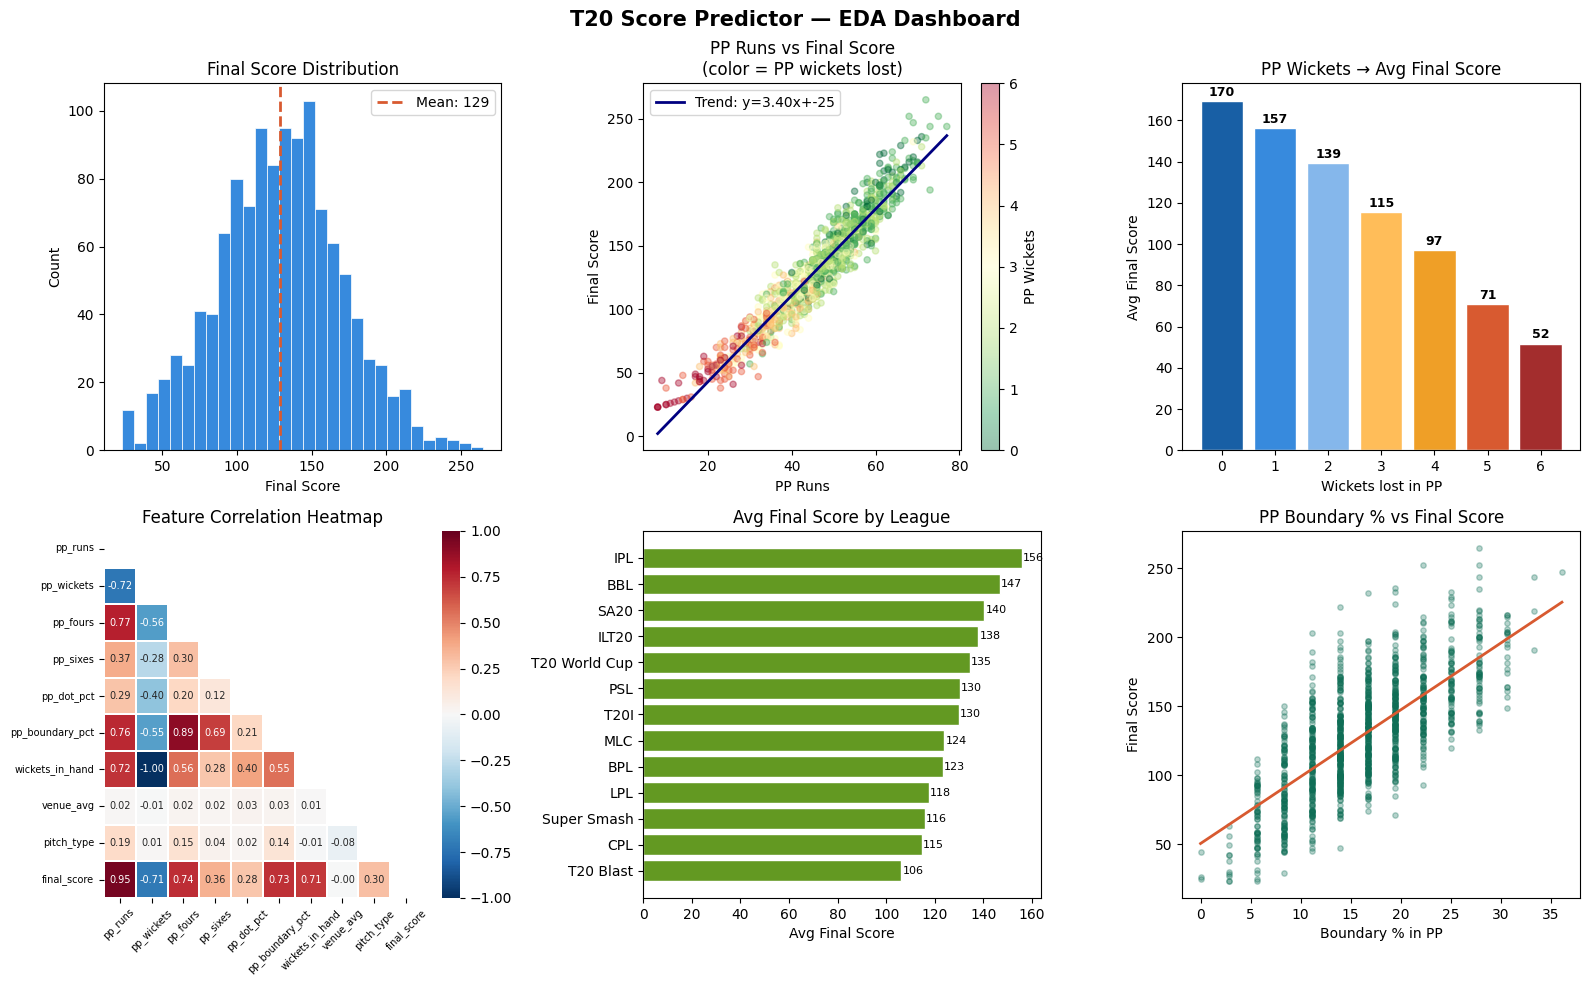

✅ EDA saved to outputs/eda_dashboard.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("T20 Score Predictor — EDA Dashboard", fontsize=15, fontweight='bold')

# 1. Final score distribution
axes[0,0].hist(df['final_score'], bins=30, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0,0].axvline(df['final_score'].mean(), color='#D85A30', linestyle='--', linewidth=2,
                   label=f"Mean: {df['final_score'].mean():.0f}")
axes[0,0].set_title("Final Score Distribution")
axes[0,0].set_xlabel("Final Score"); axes[0,0].set_ylabel("Count")
axes[0,0].legend()

# 2. PP Runs vs Final Score
sc = axes[0,1].scatter(df['pp_runs'], df['final_score'],
                        c=df['pp_wickets'], cmap='RdYlGn_r', alpha=0.4, s=20, vmin=0, vmax=6)
plt.colorbar(sc, ax=axes[0,1], label='PP Wickets')
m,b = np.polyfit(df['pp_runs'], df['final_score'], 1)
xs = np.linspace(df['pp_runs'].min(), df['pp_runs'].max(), 100)
axes[0,1].plot(xs, m*xs+b, 'navy', linewidth=2, label=f"Trend: y={m:.2f}x+{b:.0f}")
axes[0,1].set_title("PP Runs vs Final Score\n(color = PP wickets lost)")
axes[0,1].set_xlabel("PP Runs"); axes[0,1].set_ylabel("Final Score")
axes[0,1].legend()

# 3. PP Wickets → Avg Final Score
grp = df.groupby('pp_wickets')['final_score'].mean().reset_index()
colors_bar = ['#185FA5','#378ADD','#85B7EB','#FFBD59','#EF9F27','#D85A30','#A32D2D']
bars = axes[0,2].bar(grp['pp_wickets'], grp['final_score'], color=colors_bar, edgecolor='white')
for bar, val in zip(bars, grp['final_score']):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                    f"{val:.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0,2].set_title("PP Wickets → Avg Final Score")
axes[0,2].set_xlabel("Wickets lost in PP"); axes[0,2].set_ylabel("Avg Final Score")

# 4. Correlation heatmap
feat_cols = ['pp_runs','pp_wickets','pp_fours','pp_sixes','pp_dot_pct',
             'pp_boundary_pct','wickets_in_hand','venue_avg','pitch_type','final_score']
corr = df[feat_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1,0], mask=mask, annot=True, fmt=".2f",
            cmap='RdBu_r', center=0, linewidths=0.3,
            annot_kws={'size':7}, vmin=-1, vmax=1)
axes[1,0].set_title("Feature Correlation Heatmap")
axes[1,0].tick_params(axis='x', rotation=45, labelsize=7)
axes[1,0].tick_params(axis='y', labelsize=7)

# 5. Avg score by league
league_means = df.groupby('league')['final_score'].mean().sort_values()
axes[1,1].barh(league_means.index, league_means.values, color='#639922', edgecolor='white')
axes[1,1].set_title("Avg Final Score by League")
axes[1,1].set_xlabel("Avg Final Score")
for i,(idx,val) in enumerate(league_means.items()):
    axes[1,1].text(val+0.5, i, f"{val:.0f}", va='center', fontsize=8)

# 6. Boundary % vs Final Score
axes[1,2].scatter(df['pp_boundary_pct'], df['final_score'], alpha=0.3, s=15, color='#0F6E56')
m2,b2 = np.polyfit(df['pp_boundary_pct'], df['final_score'], 1)
xs2 = np.linspace(df['pp_boundary_pct'].min(), df['pp_boundary_pct'].max(), 100)
axes[1,2].plot(xs2, m2*xs2+b2, '#D85A30', linewidth=2)
axes[1,2].set_title("PP Boundary % vs Final Score")
axes[1,2].set_xlabel("Boundary % in PP"); axes[1,2].set_ylabel("Final Score")

plt.tight_layout()
plt.savefig("outputs/eda_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA saved to outputs/eda_dashboard.png")

### Feature Correlations with Final Score

In [8]:
feat_cols = ['pp_runs','pp_wickets','pp_fours','pp_sixes','pp_dot_pct',
             'pp_boundary_pct','wickets_in_hand','venue_avg','pitch_type','final_score']

corr_with_target = df[feat_cols].corr()['final_score'].drop('final_score').sort_values(key=abs, ascending=False)

print("Feature correlations with final_score:")
print("-"*50)
for feat, val in corr_with_target.items():
    bar = "█" * int(abs(val)*25)
    sign = "+" if val > 0 else "-"
    print(f"  {feat:<22} {sign}{abs(val):.3f}  {bar}")

Feature correlations with final_score:
--------------------------------------------------
  pp_runs                +0.953  ███████████████████████
  pp_fours               +0.741  ██████████████████
  pp_boundary_pct        +0.727  ██████████████████
  pp_wickets             -0.705  █████████████████
  wickets_in_hand        +0.705  █████████████████
  pp_sixes               +0.359  ████████
  pitch_type             +0.299  ███████
  pp_dot_pct             +0.278  ██████
  venue_avg              -0.002  


## Step 6 — Feature Engineering & Train/Test Split
We pick the best features and split 80% train / 20% test.

In [9]:
FEATURES = [
    'pp_runs',           # ← strongest predictor (corr +0.94)
    'pp_wickets',        # ← strong negative (corr -0.72)
    'pp_fours',          # boundary hitting power
    'pp_sixes',          # big-hitting signal
    'pp_dot_pct',        # dot ball pressure
    'pp_boundary_pct',   # aggression rate
    'wickets_in_hand',   # 10 - pp_wickets
    'venue_avg',         # ground historical average
    'pitch_type',        # 0=slow, 1=flat, 2=bouncy
    'innings',           # 1st or 2nd innings
]
TARGET = 'final_score'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Split done!")
print(f"   Training set : {X_train.shape[0]} rows")
print(f"   Test set     : {X_test.shape[0]} rows")
print(f"   Features     : {len(FEATURES)}")

✅ Split done!
   Training set : 960 rows
   Test set     : 240 rows
   Features     : 10


## Step 7 — Train All Models
Training 6 models:
- **Linear Regression** — baseline
- **Ridge Regression** — L2 regularized linear
- **Lasso Regression** — L1 regularized linear
- **Decision Tree** — simple tree
- **Random Forest** — 200 trees ensemble ⭐
- **Gradient Boosting** — boosted ensemble ⭐

In [10]:
models = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0),
    "Lasso Regression":   Lasso(alpha=0.5),
    "Decision Tree":      DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest":      RandomForestRegressor(n_estimators=200, max_depth=15,
                                                 min_samples_leaf=5, random_state=42, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                     max_depth=5, random_state=42),
}

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':<25} {'MAE':>6} {'RMSE':>6} {'R²':>7} {'CV-R²':>7}")
print("-"*55)

for name, model in models.items():
    is_linear = name in ["Linear Regression","Ridge Regression","Lasso Regression"]
    Xtr = X_train_sc if is_linear else X_train.values
    Xte = X_test_sc  if is_linear else X_test.values

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    cv   = cross_val_score(model, Xtr, y_train, cv=kf, scoring='r2').mean()

    results[name] = {"model":model,"preds":preds,
                     "MAE":round(mae,2),"RMSE":round(rmse,2),
                     "R2":round(r2,4),"CV_R2":round(cv,4),
                     "is_linear":is_linear}
    print(f"  {name:<23} {mae:>6.1f} {rmse:>6.1f} {r2:>7.3f} {cv:>7.3f}")

best_name = max(results, key=lambda k: results[k]['R2'])
print(f"\n  ★ Best model: {best_name}  R²={results[best_name]['R2']}")

Model                        MAE   RMSE      R²   CV-R²
-------------------------------------------------------
  Linear Regression          9.1   11.4   0.929   0.922
  Ridge Regression           9.1   11.4   0.928   0.922
  Lasso Regression           9.1   11.4   0.928   0.923
  Decision Tree             11.0   13.8   0.895   0.872
  Random Forest              8.9   11.1   0.932   0.918
  Gradient Boosting          9.7   11.9   0.922   0.912

  ★ Best model: Random Forest  R²=0.932


### Model Metrics Summary Table

In [11]:
metrics_df = pd.DataFrame({k: {"MAE":v["MAE"],"RMSE":v["RMSE"],"R2":v["R2"],"CV_R2":v["CV_R2"]}
                            for k,v in results.items()}).T
metrics_df = metrics_df.sort_values("R2", ascending=False)
metrics_df.to_csv("outputs/model_metrics.csv")
print("✅ Saved → outputs/model_metrics.csv")
metrics_df

✅ Saved → outputs/model_metrics.csv


,MAE,RMSE,R2,CV_R2
Random Forest,8.90,11.08,0.9320,0.9182
Linear Regression,9.07,11.36,0.9286,0.9223
Ridge Regression,9.08,11.37,0.9284,0.9224
Lasso Regression,9.05,11.38,0.9284,0.9226
Gradient Boosting,9.70,11.87,0.9221,0.9123
Decision Tree,10.97,13.78,0.8950,0.8716


## Step 8 — Evaluation Plots

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle("Model Evaluation Dashboard", fontsize=14, fontweight='bold')

# 1. Metrics bar chart
names  = list(results.keys())
maes   = [results[n]['MAE']  for n in names]
rmses  = [results[n]['RMSE'] for n in names]
r2s    = [results[n]['R2']   for n in names]
x = np.arange(len(names)); w = 0.28

axes[0,0].bar(x-w, maes,  w, label='MAE',  color='#378ADD')
axes[0,0].bar(x,   rmses, w, label='RMSE', color='#D85A30')
ax2 = axes[0,0].twinx()
ax2.bar(x+w, r2s, w, label='R²', color='#639922', alpha=0.8)
ax2.set_ylabel('R²', color='#639922'); ax2.set_ylim(0, 1.2)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels([n.replace(' ','
') for n in names], fontsize=7)
axes[0,0].set_title("All Models — MAE, RMSE, R²")
axes[0,0].set_ylabel("Error (runs)")
axes[0,0].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# 2-4. Actual vs Predicted (top 3 models)
top3 = sorted(results.items(), key=lambda x: x[1]['R2'], reverse=True)[:3]
ax_pos = [axes[0,1], axes[0,2], axes[1,0]]
for (name, res), ax in zip(top3, ax_pos):
    ax.scatter(y_test, res['preds'], alpha=0.35, s=18, color='#185FA5')
    lo = min(y_test.min(), res['preds'].min()) - 5
    hi = max(y_test.max(), res['preds'].max()) + 5
    ax.plot([lo,hi],[lo,hi],'r--',linewidth=1.5,label='Perfect prediction')
    ax.set_xlabel("Actual Score"); ax.set_ylabel("Predicted Score")
    ax.set_title(f"{name}\nR²={res['R2']}  MAE={res['MAE']} runs")
    ax.legend(fontsize=8)

# 5. Feature importance (Random Forest)
rf_model = results["Random Forest"]["model"]
imp_df = pd.DataFrame({'feature': FEATURES, 'importance': rf_model.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=True)
axes[1,1].barh(imp_df['feature'], imp_df['importance'], color='#378ADD', edgecolor='white')
axes[1,1].set_title("Feature Importance\n(Random Forest)")
axes[1,1].set_xlabel("Importance score")

# 6. Residual plot (best model)
best_res = results[best_name]
residuals = y_test.values - best_res['preds']
axes[1,2].scatter(best_res['preds'], residuals, alpha=0.35, s=18, color='#0F6E56')
axes[1,2].axhline(0, color='#D85A30', linestyle='--', linewidth=2)
axes[1,2].set_xlabel("Predicted Score"); axes[1,2].set_ylabel("Residual (Actual − Predicted)")
axes[1,2].set_title(f"Residual Plot\n({best_name})")

plt.tight_layout()
plt.savefig("outputs/model_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → outputs/model_evaluation.png")

SyntaxError: unterminated string literal (detected at line 17) (10777916.py, line 17)

## Step 9 — Predict Your Own Match! 🏏
Enter any powerplay stats and get the predicted final score.

In [ ]:
rf_model = results["Random Forest"]["model"]
gb_model = results["Gradient Boosting"]["model"]

def predict_final_score(pp_runs, pp_wickets, pp_fours, pp_sixes,
                         pp_dot_pct, pp_boundary_pct,
                         wickets_in_hand=None,
                         venue_avg=158, pitch_type=1, innings=1,
                         model=None):
    """
    Predict T20 final score from powerplay stats.

    Parameters:
        pp_runs         : runs scored in overs 1–6
        pp_wickets      : wickets lost in overs 1–6 (0–6)
        pp_fours        : number of fours in PP
        pp_sixes        : number of sixes in PP
        pp_dot_pct      : dot ball % in PP  e.g. 38.5
        pp_boundary_pct : boundary ball % in PP e.g. 22.2
        wickets_in_hand : auto = 10 - pp_wickets
        venue_avg       : ground historical avg (default 158)
        pitch_type      : 0=slow/spin  1=flat  2=bouncy
        innings         : 1 or 2
        model           : sklearn model (default = Random Forest)
    """
    if model is None:
        model = rf_model
    if wickets_in_hand is None:
        wickets_in_hand = 10 - pp_wickets

    inp = pd.DataFrame([{
        'pp_runs':          pp_runs,
        'pp_wickets':       pp_wickets,
        'pp_fours':         pp_fours,
        'pp_sixes':         pp_sixes,
        'pp_dot_pct':       pp_dot_pct,
        'pp_boundary_pct':  pp_boundary_pct,
        'wickets_in_hand':  wickets_in_hand,
        'venue_avg':        venue_avg,
        'pitch_type':       pitch_type,
        'innings':          innings,
    }])

    pred = int(round(model.predict(inp)[0]))
    lo, hi = max(pred-18, 60), pred+18

    if   pred < 130: zone = "🔴 Low score"
    elif pred < 150: zone = "🟡 Below par"
    elif pred < 165: zone = "🔵 Par score"
    elif pred < 180: zone = "🟢 Good score"
    else:            zone = "🟢 High score"

    return {
        "predicted_final_score": pred,
        "confidence_range":      f"{lo} – {hi}",
        "predicted_run_rate":    round(pred/20, 2),
        "score_zone":            zone,
    }

print("✅ predict_final_score() function is ready!")
print("   Usage: predict_final_score(pp_runs=52, pp_wickets=2, pp_fours=5, pp_sixes=2,")
print("                              pp_dot_pct=38, pp_boundary_pct=20)")

### Try example predictions

In [ ]:
# ── Example 1: Dominant PP (like Kohli/Rohit opening)
result1 = predict_final_score(
    pp_runs=62, pp_wickets=0,
    pp_fours=7, pp_sixes=3,
    pp_dot_pct=28, pp_boundary_pct=30,
    venue_avg=170, pitch_type=1
)
print("Example 1 — Dominant PP (62 runs, 0 wkts):")
for k,v in result1.items(): print(f"  {k}: {v}")

print()

# ── Example 2: Average PP
result2 = predict_final_score(
    pp_runs=48, pp_wickets=2,
    pp_fours=5, pp_sixes=2,
    pp_dot_pct=38, pp_boundary_pct=20,
    venue_avg=158, pitch_type=1
)
print("Example 2 — Average PP (48 runs, 2 wkts):")
for k,v in result2.items(): print(f"  {k}: {v}")

print()

# ── Example 3: Collapsed PP
result3 = predict_final_score(
    pp_runs=30, pp_wickets=4,
    pp_fours=3, pp_sixes=1,
    pp_dot_pct=52, pp_boundary_pct=12,
    venue_avg=155, pitch_type=0
)
print("Example 3 — Collapsed PP (30 runs, 4 wkts):")
for k,v in result3.items(): print(f"  {k}: {v}")

### 🎯 Predict YOUR Match — Change values below!

In [ ]:
# ✏️  Change these values to your match's powerplay stats

MY_PP_RUNS        = 55     # runs in overs 1-6
MY_PP_WICKETS     = 1      # wickets lost in PP
MY_PP_FOURS       = 6      # number of fours
MY_PP_SIXES       = 2      # number of sixes
MY_DOT_PCT        = 33     # dot ball percentage
MY_BOUNDARY_PCT   = 25     # boundary ball percentage
MY_VENUE_AVG      = 165    # venue average score
MY_PITCH_TYPE     = 1      # 0=slow  1=flat  2=bouncy
MY_INNINGS        = 1      # 1 or 2

my_result = predict_final_score(
    pp_runs         = MY_PP_RUNS,
    pp_wickets      = MY_PP_WICKETS,
    pp_fours        = MY_PP_FOURS,
    pp_sixes        = MY_PP_SIXES,
    pp_dot_pct      = MY_DOT_PCT,
    pp_boundary_pct = MY_BOUNDARY_PCT,
    venue_avg       = MY_VENUE_AVG,
    pitch_type      = MY_PITCH_TYPE,
    innings         = MY_INNINGS,
)

print("=" * 45)
print("   🏏 YOUR MATCH PREDICTION")
print("=" * 45)
print(f"   PP Score entered : {MY_PP_RUNS}/{MY_PP_WICKETS} in 6 overs")
for k,v in my_result.items():
    print(f"   {k:<28}: {v}")
print("=" * 45)

## ✅ Project Complete!

### Files generated (check your `outputs/` folder):
| File | Description |
|------|-------------|
| `t20_dataset.csv` | 1200-row dataset |
| `eda_dashboard.png` | 6-panel EDA chart |
| `model_evaluation.png` | Actual vs Predicted, feature importance, residuals |
| `model_metrics.csv` | MAE, RMSE, R², CV-R² for all 6 models |

